In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import mysql.connector 
import pandas as pd
config = {
    'host': '18.136.157.135',
    'port': 3306,
    'user': 'dm_team1',
    'password': 'DM!$Team&279@20!',
    'database': 'project_banking'
}
conn=mysql.connector.connect(**config)
print("Connected Successfully")
print(pd.read_sql("SHOW TABLES FROM project_banking",conn))

Connected Successfully
  Tables_in_project_banking
0              Cust_Account
1         Cust_Demographics
2              Cust_Enquiry


Here, I connect to the MySQL server using the host, port, username, and password. Then I open the project_banking database. After establishing the connection, I access the required tables using SQL queries such as SHOW TABLES.

#### Data Understanding and Data Cleaning

In [3]:
df_account=pd.read_sql("SELECT * FROM Cust_Account;",conn)
df_enquiry=pd.read_sql("SELECT * FROM Cust_Enquiry;",conn)
df_demographics=pd.read_sql("SELECT * FROM Cust_Demographics;",conn)

#### Customer Account

In [4]:
df_account.head()

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900,...,,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",,01-Sep-15,01-Jul-14,,,,,
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,,03-Oct-15,16201,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000,1400,,3,5603
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,,30-Sep-15,41028,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,,,,,
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,,26-Jul-07,31-Jan-09,93473,...,,"""""""1200900600600600300000000000000000000000000...",,01-Jul-07,01-Feb-06,,,,,
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,,31-May-15,20250,...,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,


In [5]:
df_account.shape

(186329, 21)

In [6]:
df_account.size

3912909

In [7]:
df_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186329 entries, 0 to 186328
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dt_opened            186329 non-null  object
 1   customer_no          186329 non-null  object
 2   upload_dt            186329 non-null  object
 3   acct_type            186329 non-null  object
 4   owner_indic          186329 non-null  object
 5   opened_dt            186329 non-null  object
 6   last_paymt_dt        186329 non-null  object
 7   closed_dt            186329 non-null  object
 8   reporting_dt         186329 non-null  object
 9   high_credit_amt      186329 non-null  object
 10  cur_balance_amt      186329 non-null  object
 11  amt_past_due         186329 non-null  object
 12  paymenthistory1      186329 non-null  object
 13  paymenthistory2      186329 non-null  object
 14  paymt_str_dt         186329 non-null  object
 15  paymt_end_dt         186329 non-nu

In [8]:
df_account.describe()

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
count,186329,186329,186329,186329,186329,186329,186329,186329,186329,186329,...,186329,186329,186329,186329,186329,186329,186329,186329,186329,186329
unique,197,23896,75,31,4,6246,4511,4840,1877,67555,...,630,18311,11912,234,235,1380,1456,1476,3,18300
top,16-Nov-15,8516,21-Apr-15,10,1,13-Apr-12,,,31-Jul-15,,...,,"""""""0000000000000000000000000000000000000000000...",,01-Jul-15,01-Jan-15,,,,,
freq,4643,120,5128,100239,177287,514,25487,109075,12654,8875,...,185453,44979,107824,16747,5640,137477,151047,161496,122436,145276


In [9]:
df_account.columns

Index(['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic',
       'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt',
       'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1',
       'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit',
       'cashlimit', 'rateofinterest', 'paymentfrequency',
       'actualpaymentamount'],
      dtype='object')

In [10]:
df_account.duplicated().sum()

np.int64(2401)

In [11]:
df_account.drop_duplicates(inplace=True)
print("Customer Account Shape:",df_account.shape)

Customer Account Shape: (183928, 21)


I found around 2401 duplicate rows in the dataset. I removed them to avoid bias, improve data quality and model performance, reduce training time, and ensure the model learns from unique records.

In [12]:
df_account.isnull().sum()

dt_opened              0
customer_no            0
upload_dt              0
acct_type              0
owner_indic            0
opened_dt              0
last_paymt_dt          0
closed_dt              0
reporting_dt           0
high_credit_amt        0
cur_balance_amt        0
amt_past_due           0
paymenthistory1        0
paymenthistory2        0
paymt_str_dt           0
paymt_end_dt           0
creditlimit            0
cashlimit              0
rateofinterest         0
paymentfrequency       0
actualpaymentamount    0
dtype: int64

#### Customer Enquiry

In [13]:
df_enquiry.head()

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2,3500000
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5,500000
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0,50000
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10,50000
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10,1000


In [14]:
df_enquiry.dtypes

dt_opened      object
customer_no    object
upload_dt      object
enquiry_dt     object
enq_purpose    object
enq_amt        object
dtype: object

In [15]:
df_enquiry.shape

(413188, 6)

In [16]:
df_enquiry.size

2479128

In [17]:
df_enquiry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413188 entries, 0 to 413187
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   dt_opened    413188 non-null  object
 1   customer_no  413188 non-null  object
 2   upload_dt    413188 non-null  object
 3   enquiry_dt   413188 non-null  object
 4   enq_purpose  413188 non-null  object
 5   enq_amt      413188 non-null  object
dtypes: object(6)
memory usage: 18.9+ MB


In [18]:
df_enquiry.describe()

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
count,413188,413188,413188,413188,413188,413188
unique,197,23896,76,3772,37,7384
top,16-Nov-15,10076,21-Apr-15,17-Mar-15,10,50000
freq,10538,308,11770,495,238150,79949


In [19]:
df_enquiry.columns

Index(['dt_opened', 'customer_no', 'upload_dt', 'enquiry_dt', 'enq_purpose',
       'enq_amt'],
      dtype='object')

In [20]:
df_enquiry.duplicated().sum()

np.int64(13827)

In [21]:
df_enquiry.drop_duplicates(inplace=True)
print("Customer Enquriy :",df_enquiry.shape)

Customer Enquriy : (399361, 6)


In [22]:
df_enquiry.isnull().sum()

dt_opened      0
customer_no    0
upload_dt      0
enquiry_dt     0
enq_purpose    0
enq_amt        0
dtype: int64

#### Customer Demographics

In [23]:
df_demographics.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,...,21,R,,,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,...,17,R,,,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,...,17,R,,,0000-00-00,0,98456XXXXX,1,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,...,21,R,,,6/15/65,1,98220XXXXX,1,N,0
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,...,13,R,,,0000-00-00,0,98111XXXXX,1,N,0


In [24]:
df_demographics.dtypes

dt_opened      object
customer_no    object
entry_time     object
feature_1      object
feature_2      object
                ...  
feature_76     object
feature_77     object
feature_78     object
feature_79     object
Bad_label      object
Length: 83, dtype: object

In [25]:
df_demographics.shape

(23896, 83)

In [26]:
df_demographics.columns

Index(['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12',
       'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17',
       'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22',
       'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27',
       'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32',
       'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37',
       'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42',
       'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47',
       'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52',
       'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57',
       'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62',
       '

In [27]:
df_demographics.size

1983368

In [28]:
df_demographics.duplicated().sum()

np.int64(0)

In [29]:
df_demographics.isnull().sum()

dt_opened      0
customer_no    0
entry_time     0
feature_1      0
feature_2      0
              ..
feature_76     0
feature_77     0
feature_78     0
feature_79     0
Bad_label      0
Length: 83, dtype: int64

In [30]:
df_demographics["Bad_label"].value_counts()

Bad_label
0    22892
1     1004
Name: count, dtype: int64

In [31]:
df_demographics["Bad_label"].value_counts(normalize=True)*100

Bad_label
0    95.79846
1     4.20154
Name: proportion, dtype: float64

The target variable (Bad_label) is highly imbalanced. Out of 23,896 customers, 22,892 (95.8%) are good customers, whereas only 1,004 (4.2%) are bad customers. This indicates a significant class imbalance, which should be considered during model training and evaluation.



In [32]:
print("Customer Account :",df_account.shape)
print("Customer Enquiry :",df_enquiry.shape)
print("Customer Demographics :",df_demographics.shape)

Customer Account : (183928, 21)
Customer Enquiry : (399361, 6)
Customer Demographics : (23896, 83)


#### Feature Engineering — Account & Enquiry Aggregation

In [33]:
df_account['cur_balance_amt']=pd.to_numeric(df_account['cur_balance_amt'],errors='coerce')
df_account["creditlimit"]=pd.to_numeric(df_account["creditlimit"],errors="coerce")
df_enquiry["enq_amt"]=pd.to_numeric(df_enquiry["enq_amt"],errors="coerce")

In [34]:
print("cur_balance_amt",df_account["cur_balance_amt"].isnull().sum())
print("creditlimit",df_account["creditlimit"].isnull().sum())
print("enq_amount",df_enquiry["enq_amt"].isnull().sum())

cur_balance_amt 0
creditlimit 135629
enq_amount 109


Then I converted creditlimit and cur_balance_amt to numeric using pd.to_numeric(errors='coerce') because they are used in calculations like mean() and sum()

In [35]:
agg_account=df_account.groupby('customer_no').agg(
    num_accounts=("customer_no","count"),
    avg_credit_limit=("creditlimit","mean"),
    total_balance=("cur_balance_amt","sum")
).reset_index()
print("Shape of agg_account :",agg_account.shape)
print(agg_account["avg_credit_limit"].isnull().sum())
agg_account.head()

Shape of agg_account : (23896, 4)
4024


,customer_no,num_accounts,avg_credit_limit,total_balance
0,1,18,335000.000000,4714857
1,10,12,405000.000000,247719
2,100,9,62333.333333,434425
3,1000,3,247500.000000,60462
4,10000,6,60000.000000,1086158


In [36]:
agg_enquiry=df_enquiry.groupby("customer_no").agg(
    num_enquiry=("customer_no","count"),
    avg_enquiry_amt=("enq_amt","mean")             
).reset_index()
print("Shape of agg_enquiry:",agg_enquiry.shape)
print(agg_enquiry["avg_enquiry_amt"].isnull().sum())
agg_enquiry.head()

Shape of agg_enquiry: (23896, 3)
109


,customer_no,num_enquiry,avg_enquiry_amt
0,1,18,2.767306e+05
1,10,20,5.722133e+06
2,100,19,1.298423e+05
3,1000,10,1.930000e+04
4,10000,14,8.469643e+04


The account and enquiry tables contain multiple records for each customer, whereas the demographics table has one record per customer. Since the machine learning model requires one row per customer, I grouped the account and enquiry tables by customer_no and created aggregated features such as the number of accounts, average credit limit, total balance, number of enquiries, and average enquiry amount. This allowed me to merge all the data into a single customer-level dataset without creating duplicate rows.

#### Merge

In [37]:
data=df_demographics.merge(agg_account,on="customer_no",how="left")
data=data.merge(agg_enquiry,on="customer_no",how="left")

In [38]:
data.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_76,feature_77,feature_78,feature_79,Bad_label,num_accounts,avg_credit_limit,total_balance,num_enquiry,avg_enquiry_amt
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,...,0,98332XXXXX,1,N,0,18,335000.000000,4714857,18,2.767306e+05
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,...,0,99455XXXXX,1,N,0,2,1000000.000000,30754,67,9.965122e+07
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,...,0,98456XXXXX,1,N,0,1,NaN,17864,1,3.400000e+06
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,...,1,98220XXXXX,1,N,0,17,318666.666667,1845569,33,1.509394e+06
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,...,0,98111XXXXX,1,N,0,7,NaN,7973,2,1.000000e+03


In [39]:
data.isnull().sum()[data.isnull().sum()>0]

avg_credit_limit    4024
avg_enquiry_amt      109
dtype: int64

In [40]:
data["Bad_label"] = data["Bad_label"].astype(int)

#### Feature Engineering - payment History 

In [41]:
print(df_account["paymenthistory1"].head())
print(df_account["paymenthistory1"].dtypes)

0    """STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...
1    """0000000000000000000000000000000000000000000...
2    """0000000000000000000000000000000000000000000...
3    """1200900600600600300000000000000000000000000...
4                                """000000000000000"""
Name: paymenthistory1, dtype: object
object


In [42]:
df_account["ph1_clean"]=df_account["paymenthistory1"].str.strip('"')
def parse_months(s):
    if pd.isna(s) or s=='':
        return []
    return [s[i:i+3] for i in range(0,len(s),3)]
sample=df_account["ph1_clean"].head(5).apply(parse_months)
print(sample)

0    [STD, STD, STD, XXX, XXX, XXX, XXX, XXX, STD, ...
1    [000, 000, 000, 000, 000, 000, 000, 000, 000, ...
2    [000, 000, 000, 000, 000, 000, 000, 000, 000, ...
3    [120, 090, 060, 060, 060, 030, 000, 000, 000, ...
4                            [000, 000, 000, 000, 000]
Name: ph1_clean, dtype: object


In [43]:
def get_dpd_bucket(code):
    if code =="STD":
        return 0
    elif code =="XXX":
        return -1
    else :
        try :
            days = int(code)
            return days
        except :
            return -1
def extract_dpd_feature(s):
    months=parse_months(s)
    dpd_values=[get_dpd_bucket(m) for m in months]
    dpd_values=[d for d in dpd_values if d!=-1]
    if len(dpd_values)==0:
        return pd.Series({
            'ph_avg_dpd_0_29':None,
            'ph_max_dpd':None,
            'ph_months_reported':0
        })
    dpd_0_29_count=sum(1 for d in dpd_values if 0<=d<=29)
    return pd.Series({
        'ph_avg_dpd_0_29': dpd_0_29_count / len(dpd_values),  # matches spec's "avg_dpd_0_29_bucket"
        'ph_max_dpd': max(dpd_values),                         # worst DPD ever seen
        'ph_months_reported': len(dpd_values)                  # payment_history_mean_length equivalent
    })   
test_result = df_account['ph1_clean'].head(5).apply(extract_dpd_feature)
print(test_result)

   ph_avg_dpd_0_29  ph_max_dpd  ph_months_reported
0         1.000000         0.0                 5.0
1         1.000000         0.0                18.0
2         1.000000         0.0                18.0
3         0.666667       120.0                18.0
4         1.000000         0.0                 5.0


Payment History Feature Engineering: I created this code to convert the raw payment history into meaningful numerical features for machine learning. First, I converted payment status codes such as STD (standard payment) to 0 and XXX (missing payment history) to -1. Numeric DPD values like 030, 060, and 090 were converted into integers. Then, I removed all invalid (-1) values and extracted important features such as the proportion of months with DPD between 0–29 days (ph_avg_dpd_0_29), the maximum DPD (ph_max_dpd), and the total number of valid payment months (ph_months_reported). Finally, I tested the function on the first five records using apply() to verify that the features were generated correctly.

In [44]:
dpd_feature=df_account["ph1_clean"].apply(extract_dpd_feature)
df_account=pd.concat([df_account,dpd_feature],axis=1)
print(df_account.shape)
df_account[["paymenthistory1","ph_avg_dpd_0_29","ph_max_dpd","ph_months_reported"]]

(183928, 25)


,paymenthistory1,ph_avg_dpd_0_29,ph_max_dpd,ph_months_reported
0,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",1.000000,0.0,5.0
1,"""""""0000000000000000000000000000000000000000000...",1.000000,0.0,18.0
2,"""""""0000000000000000000000000000000000000000000...",1.000000,0.0,18.0
3,"""""""1200900600600600300000000000000000000000000...",0.666667,120.0,18.0
4,"""""""000000000000000""""""",1.000000,0.0,5.0
...,...,...,...,...
186324,"""""""0000000000000000000000000000000000000000000...",1.000000,0.0,18.0
186325,"""""""000179146119089058029000XXX""""""",0.375000,179.0,8.0
186326,"""""""000XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...",1.000000,0.0,1.0
186327,"""""""000010000000000000000000000000000XXXXXXXXXX...",1.000000,10.0,11.0


In [45]:
dpd_agg=df_account.groupby("customer_no").agg(
    avg_dpd_0_29=("ph_avg_dpd_0_29","mean"),
    worst_dpd_ever=("ph_max_dpd","max"),
    avg_months_reported=("ph_months_reported","mean")
).reset_index()
print(dpd_agg.shape)
print(dpd_agg.head())

(23896, 4)
  customer_no  avg_dpd_0_29  worst_dpd_ever  avg_months_reported
0           1      0.916667           181.0             7.777778
1          10      0.983333            30.0            10.750000
2         100      1.000000             0.0             8.444444
3        1000      1.000000             0.0            11.333333
4       10000      1.000000             0.0             6.833333


In [46]:
data=data.merge(dpd_agg,on="customer_no",how="left")
print(data.shape)
data[["customer_no","avg_dpd_0_29","worst_dpd_ever","avg_months_reported"]].head()

(23896, 91)


,customer_no,avg_dpd_0_29,worst_dpd_ever,avg_months_reported
0,1,0.916667,181.0,7.777778
1,2,1.000000,0.0,17.500000
2,3,1.000000,0.0,18.000000
3,4,0.957734,210.0,11.647059
4,5,1.000000,0.0,10.714286


In [47]:
data[["customer_no","avg_dpd_0_29","worst_dpd_ever","avg_months_reported"]].isnull().sum()

customer_no            0
avg_dpd_0_29           0
worst_dpd_ever         0
avg_months_reported    0
dtype: int64

#### Check the numerical and categorical 

In [48]:
feature_col=[]
for c in data.columns :
    if c.startswith("feature_"):
        feature_col.append(c)
converted_check=data[feature_col].apply(pd.to_numeric,errors="coerce")
print("Total NANs introduced",converted_check.isnull().sum().sum())
print(converted_check.isnull().sum()[converted_check.isnull().sum()>0])

Total NANs introduced 1179460
feature_1     23896
feature_2     23896
feature_3      2836
feature_4        15
feature_5     23896
              ...  
feature_75    23896
feature_76       15
feature_77    23896
feature_78       15
feature_79    23896
Length: 79, dtype: int64


In [49]:
nan_counts = converted_check.isnull().sum()
total_rows = len(data)
# Columns where conversion mostly succeeded (numeric)
numeric_features = nan_counts[nan_counts < total_rows * 0.5].index.tolist()
# Columns where conversion mostly failed (categorical)
categorical_features = nan_counts[nan_counts >= total_rows * 0.5].index.tolist()
print("Numeric feature columns:", len(numeric_features))
print("Categorical feature columns:", len(categorical_features))
print("\nCategorical columns:", categorical_features)

Numeric feature columns: 30
Categorical feature columns: 49

Categorical columns: ['feature_1', 'feature_2', 'feature_5', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_53', 'feature_54', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_70', 'feature_72', 'feature_73', 'feature_74', 'feature_75', 'feature_77', 'feature_79']


In [50]:
for col in numeric_features:
    data[col] = pd.to_numeric(data[col], errors='coerce')
print(data[numeric_features].dtypes.value_counts())
print(data[numeric_features].isnull().sum().sum(), "total NaNs in numeric features")

float64    30
Name: count, dtype: int64
10989 total NaNs in numeric features


In [51]:
for col in categorical_features:
    print(col, "-", data[col].nunique(), "unique values")

feature_1 - 8 unique values
feature_2 - 282 unique values
feature_5 - 2 unique values
feature_8 - 20 unique values
feature_9 - 20 unique values
feature_10 - 8 unique values
feature_11 - 3 unique values
feature_12 - 17 unique values
feature_13 - 15 unique values
feature_15 - 365 unique values
feature_16 - 523 unique values
feature_17 - 303 unique values
feature_18 - 13 unique values
feature_20 - 10610 unique values
feature_21 - 8463 unique values
feature_22 - 3251 unique values
feature_23 - 3 unique values
feature_24 - 722 unique values
feature_27 - 11 unique values
feature_28 - 63 unique values
feature_32 - 6 unique values
feature_33 - 3 unique values
feature_36 - 10 unique values
feature_37 - 12 unique values
feature_38 - 5664 unique values
feature_43 - 71 unique values
feature_45 - 4473 unique values
feature_46 - 6 unique values
feature_47 - 11250 unique values
feature_48 - 57 unique values
feature_49 - 19 unique values
feature_50 - 3 unique values
feature_51 - 11 unique values
featu

#### Group A: Low cardinality (2–20 unique)
feature_1, feature_5, feature_8, feature_9, feature_10, feature_11, feature_12, 
feature_13, feature_18, feature_23, feature_27, feature_32, feature_33, feature_36, 
feature_37, feature_46, feature_49, feature_50, feature_51, feature_54, feature_57, 
feature_58, feature_59, feature_60, feature_61, feature_62, feature_72, feature_73, 
feature_74, feature_79

#### Group B: Medium cardinality (21–200 unique)
feature_28 (63), feature_43 (71), feature_48 (57), feature_53 (181), 
feature_70 (134), feature_75 (63)

#### Group C: High cardinality (200+ unique)
feature_2 (282), feature_15 (365), feature_16 (523), feature_17 (303), 
feature_20 (10610), feature_21 (8463), feature_22 (3251), feature_24 (722), 
feature_38 (5664), feature_45 (4473), feature_47 (11250), feature_63 (492), 
feature_77 (3124)

#### Inspect Group B and C

In [52]:
for col in ['feature_28','feature_43','feature_48','feature_53','feature_70','feature_75']:
    print(col,data[col].unique()[:10])
    print()

feature_28 ['Mumbai / Navi Mumbai / Thane' 'Bengaluru' 'Pune' 'Gurgaon' 'New Delhi'
 'Kolhapur' 'Noida / Greater Noida' 'Chennai' 'Kolkata / Howrah'
 'Vadodara']

feature_43 ['Mumbai' 'Bangalore' 'Pune' 'Gurgaon' 'New Delhi' 'Kolhapur' 'Chennai'
 'Kolkata' 'Vadodara' 'Nagpur']

feature_48 ['The Ratnakar Bank Ltd.' '' 'AXIS Bank' 'HDFC Bank'
 'Kotak Mahindra Bank Ltd.' 'State Bank of India' 'ICICI Bank'
 'Canara Bank' 'Indian Overseas Bank' 'Union Bank of India']

feature_53 ['01-Jun-13' '' '01-Jun-14' '01-Jan-10' '01-Oct-05' '01-Oct-14'
 '01-Aug-14' '01-Apr-14' '01-Mar-02' '01-Nov-13']

feature_70 ['Nov-00' '0-0' 'Apr-00' 'May-00' 'Jul-00' '05-Mar' 'Feb-00' '02-Jul'
 '0-6' '01-Oct']

feature_75 ['0000-00-00' '6/15/65' '10/27/63' '09-01-1960' '10/16/71' '1/15/96'
 '10/26/84' '05-11-1984' '04-01-1954' '07-06-1970']



In [53]:
for col in ['feature_2','feature_15','feature_16','feature_17','feature_20',
            'feature_47','feature_21','feature_22','feature_38','feature_45','feature_77','feature_24',"feature_63"]:
    print(col,data[col].unique()[:10])
    print()

feature_2 ['13-Apr-15' '21-Apr-15' '20-Apr-15' '' '06-May-15' '15-May-15'
 '27-May-15' '28-May-15' '02-Jun-15' '23-May-15']

feature_15 ['159' '91' '157' '100' '88' '141' '20' '4611' '155' '180']

feature_16 ['4284' 'B001' '5107' 'D016' '5231' '5957' '5785' 'D068' '3140' 'K001']

feature_17 ['4284' '4077' '5107' '4564' '5231' '6031' '5785' '3140' '5455' '5717']

feature_20 ['ADFPNXXXXX' 'AJWPRXXXXX' 'AFAPNXXXXX' 'AAAPDXXXXX' 'ABEPSXXXXX'
 'ABQPNXXXXX' 'AAKPDXXXXX' 'ABZPDXXXXX' 'AAFPDXXXXX' 'AAHPGXXXXX']

feature_47 ['ADFPNXXXXX' 'AJWPRXXXXX' 'AFAPNXXXXX' 'AAAPDXXXXX' 'ABEPSXXXXX' 'XXXXX'
 'AAKPDXXXXX' 'ABZPDXXXXX' 'AAFPDXXXXX' 'AAHPGXXXXX']

feature_21 ['03-Sep-65' '14-Jul-62' '10-Apr-66' '16-Apr-64' '03-Jan-54' '10-Jul-63'
 '22-Apr-54' '26-Apr-51' '01-Sep-77' '09-Oct-69']

feature_22 ['98332XXXXX' '99455XXXXX' '98456XXXXX' '98220XXXXX' '98111XXXXX'
 '99202XXXXX' '98100XXXXX' '96865XXXXX' '99676XXXXX' '98738XXXXX']

feature_38 ['' 'ADMIN OFFICER' 'CHAIRPERSON' 'DIRECTOR' 'FOUNDER DIREC

#### Categorical Cleaning

In [54]:
columns_to_drop=["feature_15","feature_16","feature_17","feature_20","feature_47","feature_22","feature_45",
                "feature_24","feature_77","feature_63"]
data=data.drop(columns=columns_to_drop)
print(data.shape)
print(data.columns.tolist())

(23896, 81)
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_18', 'feature_19', 'feature_21', 'feature_23', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_46', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_69', 'feature_70', 'feature_71', 'feature_72', 'feature_73', 'feature_74', 'feature_75', 'feature_76', 'feature_78', 'f

During EDA, several of the 79 anonymized demographic features were found to be high-cardinality identifier fields rather than true categorical variables — including masked PAN numbers, masked phone numbers, email domains, and branch/product codes (feature_15, 16, 17, 20, 22, 24, 45, 47, 63, 77). These columns had hundreds to thousands of unique values relative to the ~24,000 customers, meaning they were effectively unique per customer and carried no generalizable predictive signal. They were therefore dropped from the feature set, both to avoid noise/overfitting and to align with privacy best practices around masked personal identifiers.

In [55]:
for col in ["feature_2","feature_21","feature_53","feature_70","feature_75"]:
    converted=pd.to_datetime(data[col],errors="coerce",dayfirst=True)
    print(col)
    print("Min :",converted.min(),"Max :",converted.max())
    print("Nulls after conversion :",converted.isnull().sum().sum())
    print()

feature_2
Min : 2015-02-02 00:00:00 Max : 2015-12-24 00:00:00
Nulls after conversion : 2836

feature_21
Min : 1976-01-01 00:00:00 Max : 2075-12-31 00:00:00
Nulls after conversion : 15

feature_53
Min : 1989-06-01 00:00:00 Max : 2015-10-01 00:00:00
Nulls after conversion : 11610

feature_70
Min : NaT Max : NaT
Nulls after conversion : 23896

feature_75
Min : 1940-08-09 00:00:00 Max : 2075-12-22 00:00:00
Nulls after conversion : 23835



feature_2: Range 2015-02-02 to 2015-12-24, all within one year → this is clearly an event date (account entry/application date), not DOB. 2,836 nulls (blanks).

feature_21: Range 1976 to 2075 — that max is impossible; nobody has a birth year of 2075. This is a classic 2-digit year parsing bug: dates like 03-Sep-65 get parsed as 2065 instead of 1965 by default. We need to fix this before extracting age, or ages will be wildly wrong (negative or absurd for ~half the customers).

feature_53: Range 1989–2015, but 11,610 nulls (~49% missing) — very high missingness, may limit its usefulness.

feature_70: 100% null (23,896/23,896) — this column simply cannot be parsed as a standard date (matches what we saw earlier: Nov-00, 0-0, 05-Mar — inconsistent/broken formats). Not usable — should be dropped.
feature_75: 23,835 out of 23,896 null (~99.7%) — essentially unusable. Should be dropped.

In [56]:
data=data.drop(columns=["feature_70","feature_75"])

In [57]:
event_date=pd.to_datetime(data["feature_2"],errors="coerce",dayfirst=True)
dob=pd.to_datetime(data["feature_21"],errors="coerce",dayfirst=True)
dob=dob.apply(lambda d :d.replace(year=d.year-100) if pd.notnull(d) and d.year>2015 else d)
reference_date=event_date.max()
data["age"]=(reference_date-dob).dt.days//365
print(data["age"].head())

0    50.0
1    53.0
2    49.0
3    51.0
4    62.0
Name: age, dtype: float64


Extracted customer age from the DOB field (feature_21), correcting a 2-digit year parsing issue (dates like '03-Sep-65' were initially misinterpreted as 2065 instead of 1965). Reference date was derived from the data's own application date range (feature_2) rather than the current date, since this dataset represents a 2015 snapshot. Resulting age distribution (18–76, median 32) aligns with expected credit card customer demographics.

In [58]:
data["age"].describe()

count    23881.000000
mean        33.851807
std          7.362743
min         18.000000
25%         29.000000
50%         32.000000
75%         37.000000
max         76.000000
Name: age, dtype: float64

In [59]:
data=data.drop(columns=["feature_2","feature_21","feature_53"])

In [60]:
print(data.shape)

(23896, 77)


In [61]:
data.to_csv("bank_data_progress",index=False)
print("Saved_successfully")

Saved_successfully


In [62]:
Categorical_to_encode=[c for c in ['feature_1','feature_5','feature_8','feature_9','feature_10','feature_11',
    'feature_12','feature_13','feature_18','feature_23','feature_27','feature_28',
    'feature_32','feature_33','feature_36','feature_37','feature_38','feature_43',
    'feature_46','feature_48','feature_49','feature_50','feature_51','feature_54',
    'feature_57','feature_58','feature_59','feature_60','feature_61','feature_62',
    'feature_72','feature_73','feature_74','feature_79'
]if c in data.columns]

print("Categorical columns :",len(Categorical_to_encode))
for col in Categorical_to_encode:
    print(col,data[col].nunique())
    


Categorical columns : 34
feature_1 8
feature_5 2
feature_8 20
feature_9 20
feature_10 8
feature_11 3
feature_12 17
feature_13 15
feature_18 13
feature_23 3
feature_27 11
feature_28 63
feature_32 6
feature_33 3
feature_36 10
feature_37 12
feature_38 5664
feature_43 71
feature_46 6
feature_48 57
feature_49 19
feature_50 3
feature_51 11
feature_54 2
feature_57 3
feature_58 3
feature_59 3
feature_60 3
feature_61 9
feature_62 3
feature_72 3
feature_73 3
feature_74 4
feature_79 3


In [63]:
data=data.drop(columns=["feature_38","feature_43"])
print(data.shape)

(23896, 75)


In [64]:
data.to_csv("bank_data_progress.csv",index=False)
print("Saved_successfully")

Saved_successfully


Slightly differently — "Manager" vs "MANAGER" vs "Sr. Manager", etc.), making it nearly as unique as an ID. One-hot encoding this directly would create 5,664 new columns . completely impractical and would badly overfit.

Drop one of them (I'd drop feature_43 since feature_28 seems slightly more descriptive/original).

In [65]:
def group_rare_categories(series, top_n=10):
    top_categories=series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top_categories),'other')
data["feature_28"]=group_rare_categories(data['feature_28'],top_n=10)
data["feature_48"]=group_rare_categories(data['feature_48'],top_n=10)
print(data["feature_28"].value_counts())
print(data["feature_48"].value_counts())

feature_28
New Delhi                       12539
Hyderabad / Secunderabad         2218
Mumbai / Navi Mumbai / Thane     1708
Ghaziabad                        1410
Gurgaon                          1405
other                            1267
Faridabad                        1074
Noida / Greater Noida             863
Bengaluru                         539
Ahmedabad                         482
Vadodara                          391
Name: count, dtype: int64
feature_48
                            18399
HDFC Bank                    1368
ICICI Bank                   1130
other                         976
AXIS Bank                     528
The Ratnakar Bank Ltd.        456
State Bank of India           382
Kotak Mahindra Bank Ltd.      210
Citibank N.A.                 194
Standard Chartered Bank       133
Yes Bank                      120
Name: count, dtype: int64


#### EDA Part 

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

#### Univariate Analysis

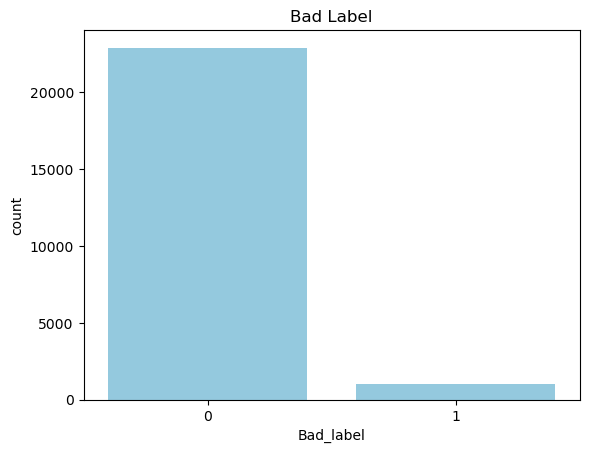

Bad_Label is Highly Imbalanced


In [67]:
sns.countplot(x="Bad_label",data=data,color="skyblue")
plt.title("Bad Label")
plt.show()
print("Bad_Label is Highly Imbalanced")

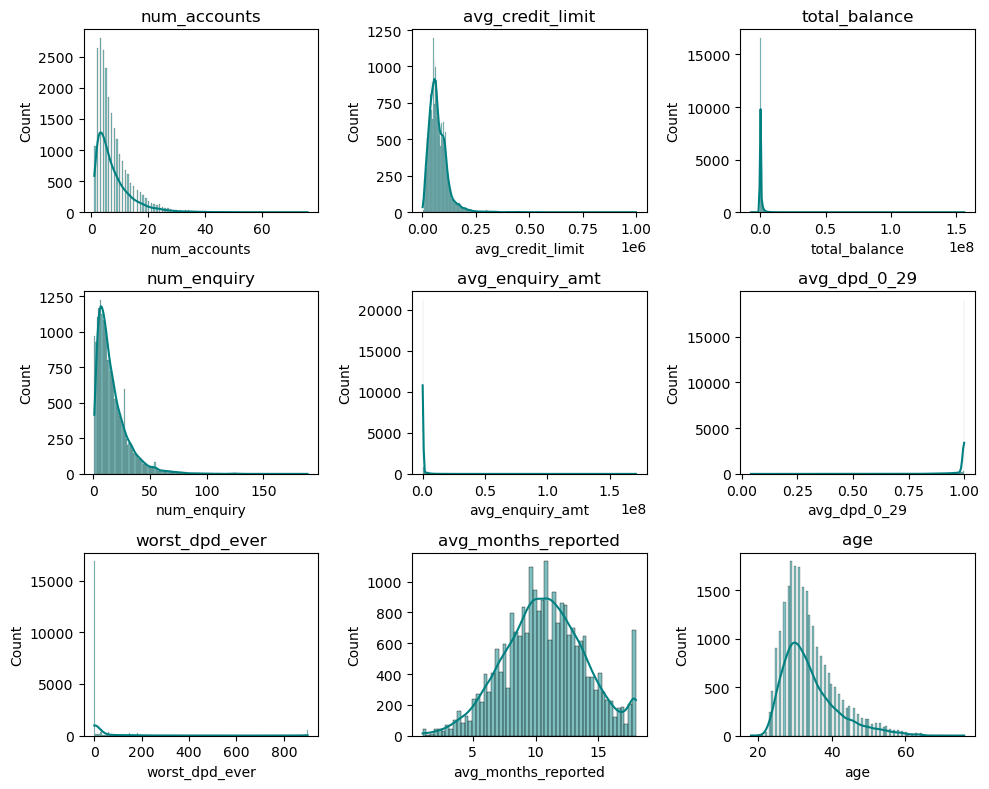

In [68]:
numeric_features = ['num_accounts', 'avg_credit_limit', 'total_balance',
    'num_enquiry', 'avg_enquiry_amt', 'avg_dpd_0_29', 'worst_dpd_ever',
    'avg_months_reported', 'age']
plt.figure(figsize=(10,8))
for i,col in enumerate(numeric_features,1):
    plt.subplot(3,3,i)
    sns.histplot(x=col,data=data,color='teal',kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

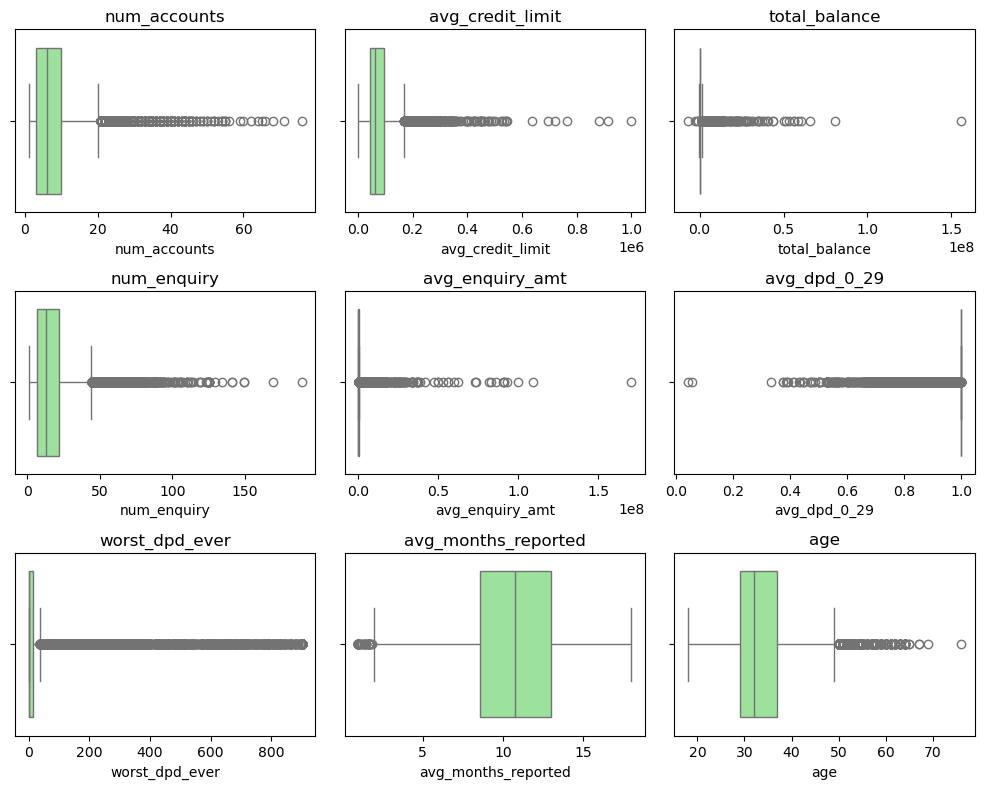

Checking Outliers


In [69]:
check_outlier=["num_accounts","avg_credit_limit","total_balance","num_enquiry","avg_enquiry_amt","avg_dpd_0_29",
"worst_dpd_ever","avg_months_reported",'age']
plt.figure(figsize=(10,8))
for o,out in enumerate(check_outlier,1):
    plt.subplot(3,3,o)
    sns.boxplot(x=out,data=data,color="lightgreen")
    plt.title(out)
plt.tight_layout()
plt.show()
print("Checking Outliers")

#### Bivariate Analysis

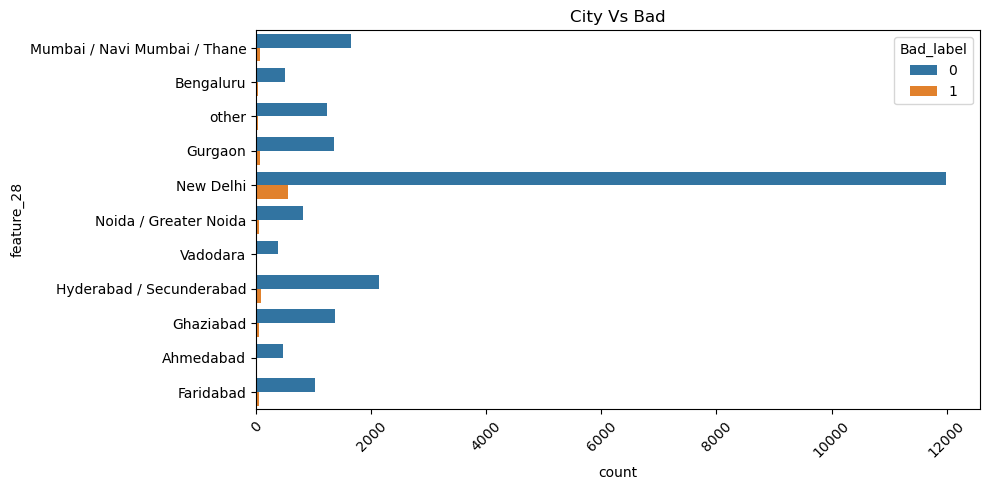

In [70]:
plt.figure(figsize=(10,5))
sns.countplot(y='feature_28',hue="Bad_label",data=data)
plt.title("City Vs Bad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

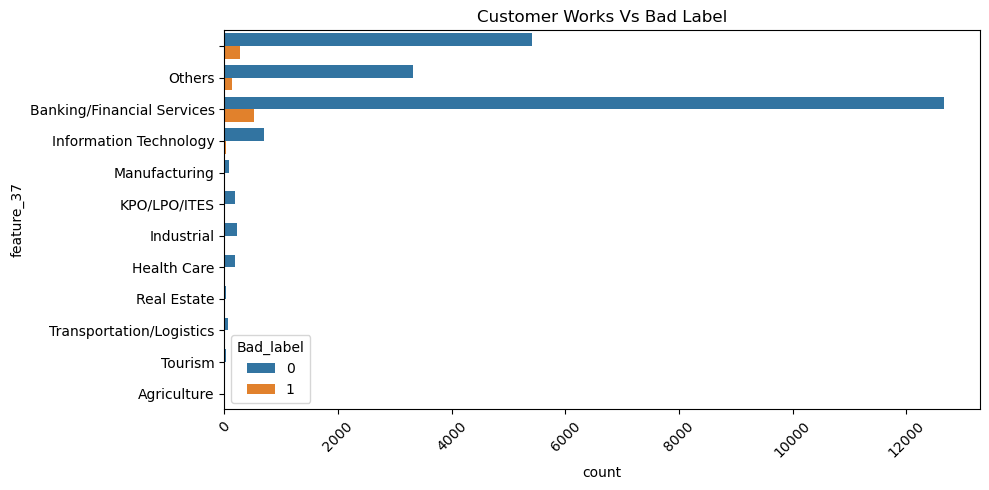

In [71]:
plt.figure(figsize=(10,5))
sns.countplot(y='feature_37',hue="Bad_label",data=data)
plt.title("Customer Works Vs Bad Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

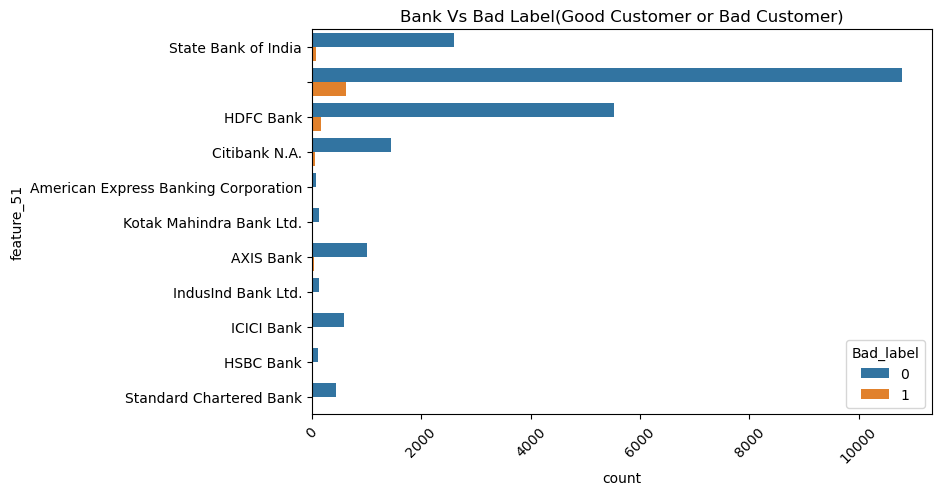

In [72]:
plt.figure(figsize=(8,5))
sns.countplot(y='feature_51',hue="Bad_label",data=data)
plt.title("Bank Vs Bad Label(Good Customer or Bad Customer)")
plt.xticks(rotation=45)
plt.show()

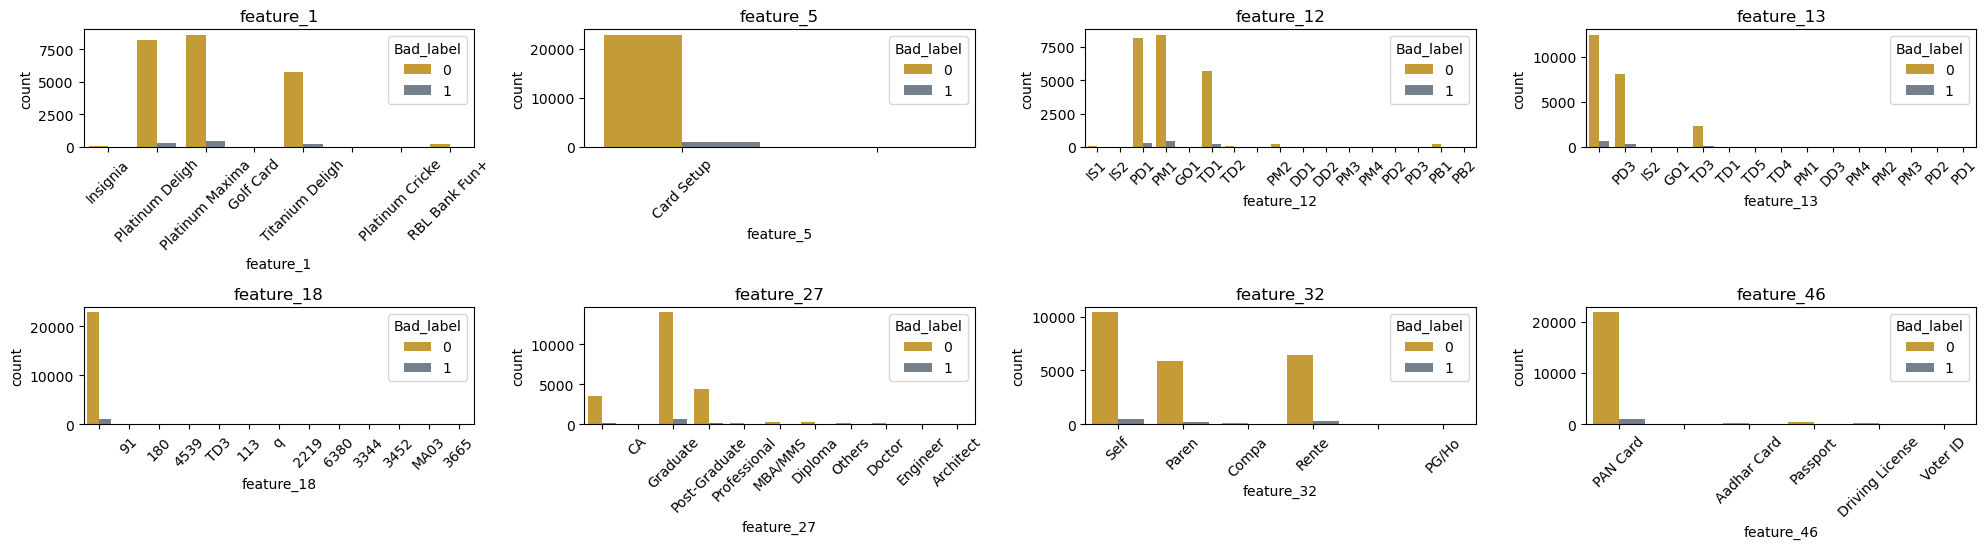

In [73]:
features = ['feature_1', 'feature_5', 'feature_12', 'feature_13',
    'feature_18', 'feature_27', 'feature_32', 'feature_46']
plt.figure(figsize=(20,10))
for i ,col in enumerate(features,1):
    plt.subplot(4,4,i)
    sns.countplot(x=col,hue="Bad_label",data=data,palette=["goldenrod","slategray"])
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

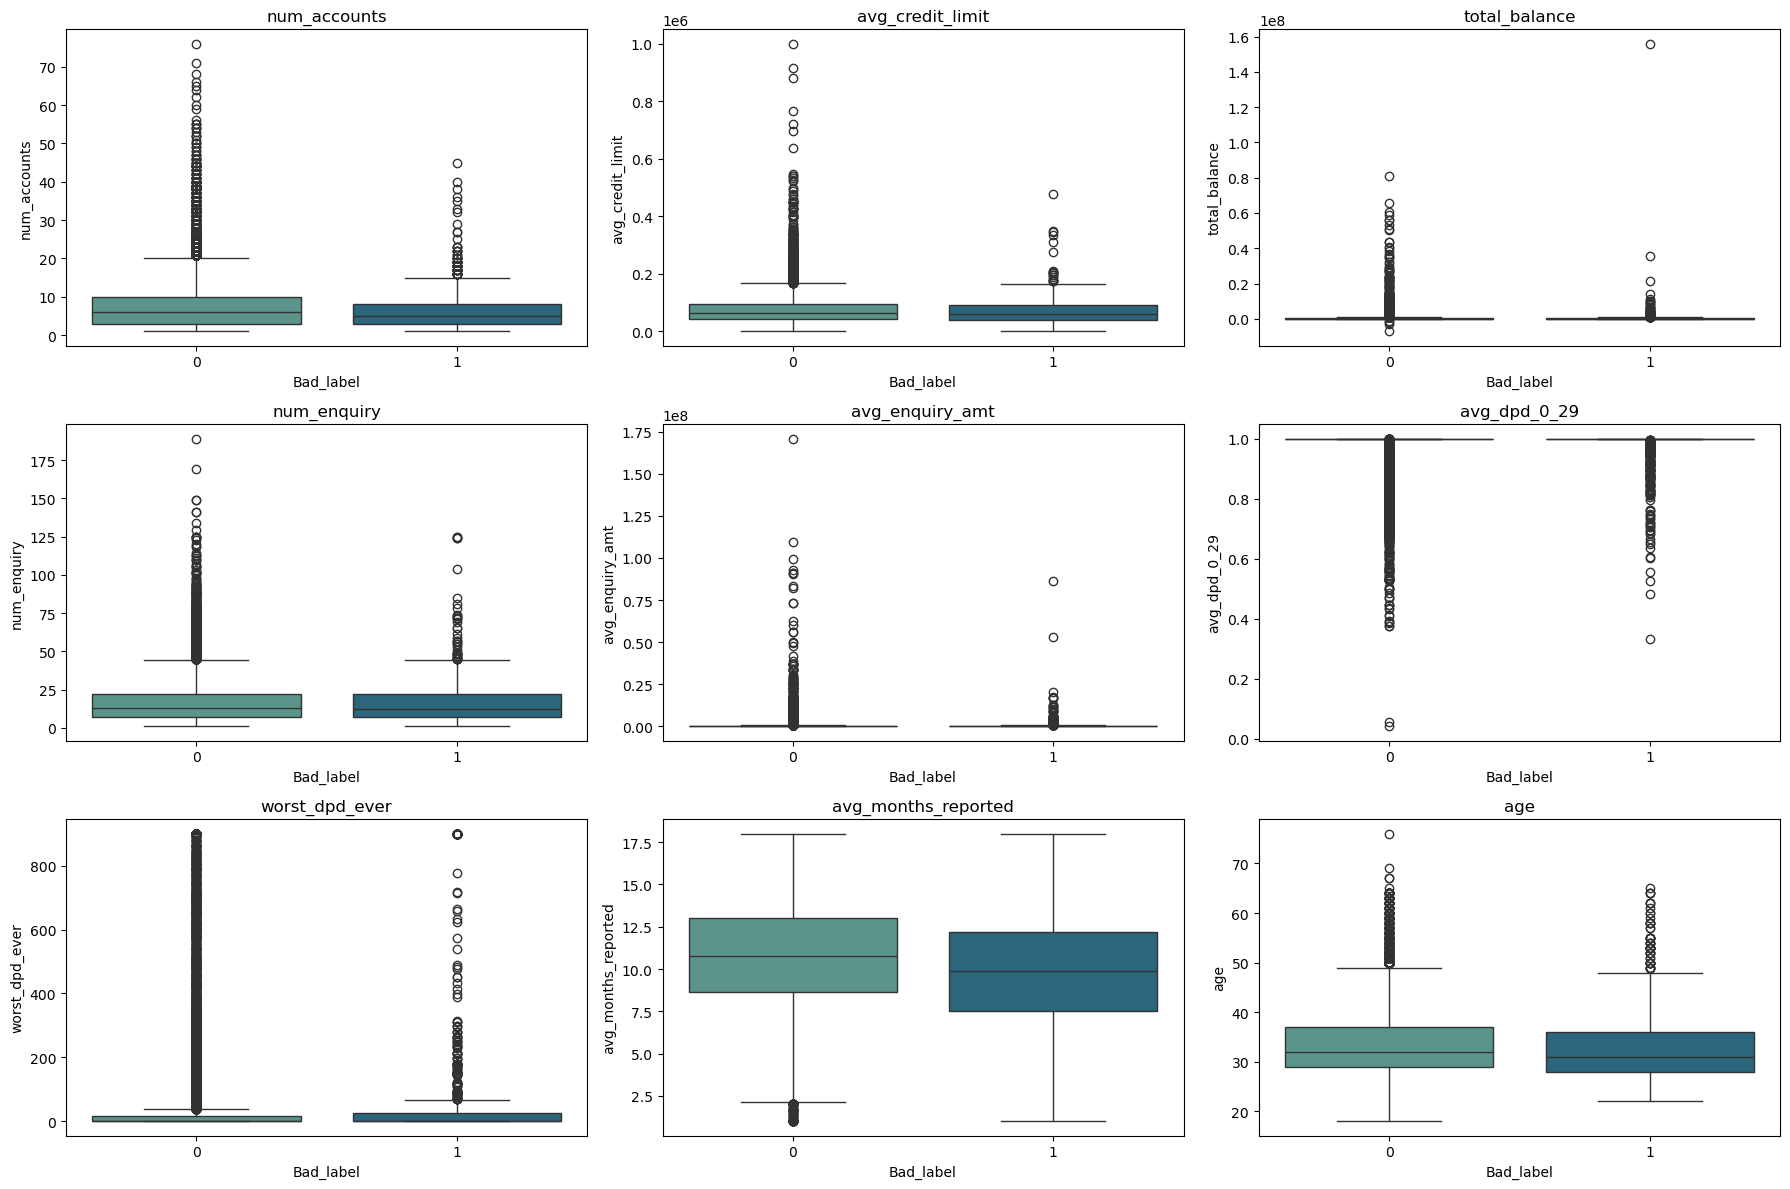

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_col = [
    "num_accounts", "avg_credit_limit", "total_balance",
    "num_enquiry", "avg_enquiry_amt", "avg_dpd_0_29",
    "worst_dpd_ever", "avg_months_reported", "age"]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, col in zip(axes, numeric_col):
    sns.boxplot(data=data,x="Bad_label",y=col,ax=ax,palette="crest")
    ax.set_title(col)
plt.tight_layout()
plt.show()

<Axes: >

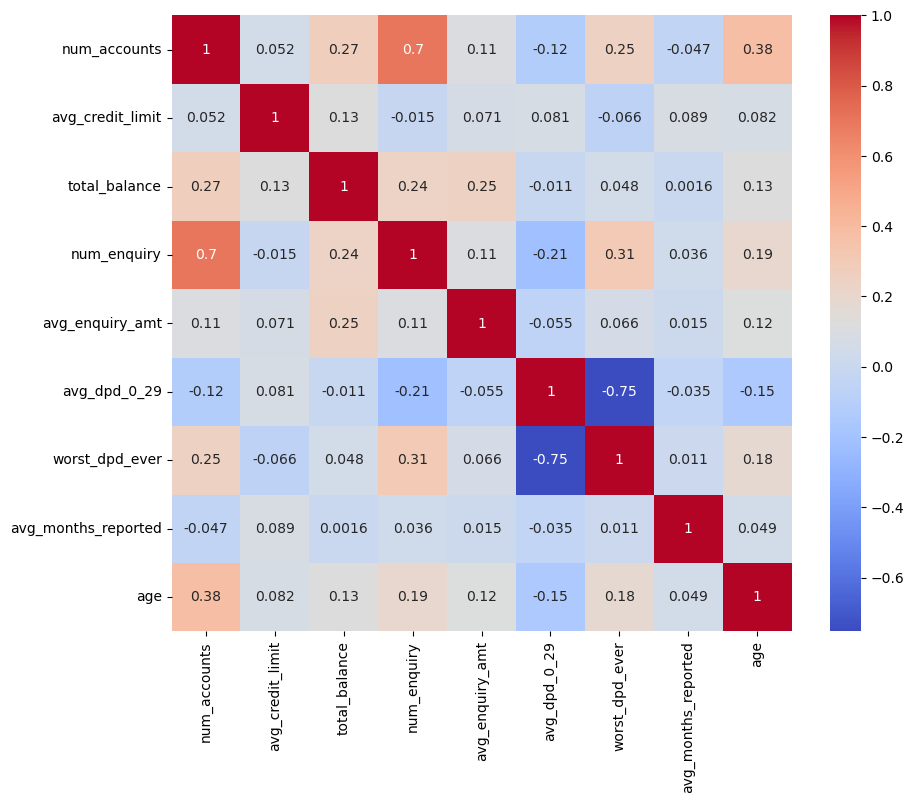

In [75]:
numeric=["num_accounts","avg_credit_limit","total_balance","num_enquiry","avg_enquiry_amt","avg_dpd_0_29",
"worst_dpd_ever","avg_months_reported",'age']
plt.figure(figsize=(10,8))
sns.heatmap(data[numeric].corr(),annot=True,cmap="coolwarm")

num_accounts and num_enquiries show a strong positive correlation (0.70), indicating that customers with more accounts tend to have more credit enquiries.

avg_dpd_0_29 and worst_dpd_ever show a strong negative correlation (-0.75), indicating an inverse relationship between these two DPD features.

Most other feature pairs have weak to moderate correlations, suggesting low multicollinearity and that the engineered features provide relatively independent information for model training.

#### Convert One-Hot Encoding and Handle Missing Values

In [76]:
data.isnull().sum()[data.isnull().sum()>0]

feature_3           2836
feature_4             15
feature_6             15
feature_7             15
feature_14          7733
feature_19            15
feature_25            15
feature_26            15
feature_29            15
feature_30            15
feature_31            15
feature_34            15
feature_35            15
feature_39            15
feature_40            15
feature_41            15
feature_42            15
feature_44            15
feature_52            15
feature_55            15
feature_56            15
feature_64            15
feature_65            15
feature_66            15
feature_67            15
feature_68            15
feature_69            15
feature_71            15
feature_76            15
feature_78            15
avg_credit_limit    4024
avg_enquiry_amt      109
age                   15
dtype: int64

In [77]:
data.duplicated().sum()

np.int64(0)

In [78]:
data=data.drop(columns=["feature_48","feature_49","feature_54","dt_opened","entry_time"])
data.shape

(23896, 70)

In [79]:
data.to_csv("bank_data_progress.csv",index=False)
print("Saved_successfully")

Saved_successfully


Five columns were dropped prior to final feature encoding: feature_48 (bank name, ~77% missing and redundant with feature_51), feature_49 (numeric ID/phone-like values with no categorical meaning), feature_54 (near-constant value across nearly all records, providing no discriminative signal), and dt_opened/entry_time (raw unused date/timestamp fields with no engineered predictive value). Removing these columns reduces noise and redundancy in the final feature set without losing meaningful information.

#### One-Hot Encoding

In [80]:
categorical_to_encode = [c for c in [
    'feature_1','feature_5','feature_8','feature_9','feature_10','feature_11',
    'feature_12','feature_13','feature_18','feature_23','feature_27','feature_28',
    'feature_32','feature_33','feature_36','feature_37','feature_46','feature_50',
    'feature_51','feature_57','feature_58','feature_59','feature_60',
    'feature_61','feature_62','feature_72','feature_73','feature_74','feature_79'
] if c in data.columns]
print(len(categorical_to_encode),"Categorical to encode")
data=pd.get_dummies(data,columns=categorical_to_encode,drop_first=True)
print(data.shape)

29 Categorical to encode
(23896, 231)


In [81]:
data.to_csv("bank_data_progress.csv",index=False)
print("Saved_successfully")

Saved_successfully


In [82]:
X=data.drop(['customer_no','Bad_label'],axis=1)

In [83]:
y=data["Bad_label"]

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [85]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
X_train=pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test=pd.DataFrame(imputer.transform(X_test),columns=X_test.columns,index=X_test.index)
print("Check the null values in :",X_train.isnull().sum().sum())
print("Check the null values in :",X_test.isnull().sum().sum())

Check the null values in : 0
Check the null values in : 0


In [86]:
import numpy as np

In [87]:
print((X_train['feature_69'] == X_train['feature_35']).all())

True


In [88]:
X_train = X_train.drop(columns=['feature_35'])
X_test = X_test.drop(columns=['feature_35'])
print("feature_35 dropped. Remaining shape:", X_train.shape)

feature_35 dropped. Remaining shape: (19116, 228)


In [89]:
dupe_pairs = []
cols = X_train.select_dtypes(include=[np.number]).columns
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        if X_train[c1].equals(X_train[c2]):
            dupe_pairs.append((c1, c2))
print(dupe_pairs)

[('feature_34', 'feature_68'), ('feature_67', 'feature_33_N'), ('feature_1_Golf Card', 'feature_12_GO1'), ('feature_8_RCBL', 'feature_8_RCBNH'), ('feature_8_RCBL', 'feature_8_RNOA'), ('feature_8_RCBL', 'feature_8_RROCL'), ('feature_8_RCBL', 'feature_9_CIBIL Guidelines Not Met'), ('feature_8_RCBL', 'feature_9_CIBIL No Hit'), ('feature_8_RCBL', 'feature_9_Not Applied'), ('feature_8_RCBL', 'feature_9_Residence Outside City Limits'), ('feature_8_RCBL', 'feature_10_1.00E+15'), ('feature_8_RCBL', 'feature_10_5.54E+15'), ('feature_8_RCBL', 'feature_12_PM3'), ('feature_8_RCBL', 'feature_18_3452'), ('feature_8_RCBL', 'feature_18_q'), ('feature_8_RCBL', 'feature_61_631280'), ('feature_8_RCBNH', 'feature_8_RNOA'), ('feature_8_RCBNH', 'feature_8_RROCL'), ('feature_8_RCBNH', 'feature_9_CIBIL Guidelines Not Met'), ('feature_8_RCBNH', 'feature_9_CIBIL No Hit'), ('feature_8_RCBNH', 'feature_9_Not Applied'), ('feature_8_RCBNH', 'feature_9_Residence Outside City Limits'), ('feature_8_RCBNH', 'feature_10

In [90]:
import networkx as nx
G = nx.Graph()
G.add_nodes_from(X_train.columns)
G.add_edges_from(dupe_pairs)  # dupe_pairs from your last check
groups = [list(c) for c in nx.connected_components(G) if len(c) > 1]
to_drop = []
for g in groups:
    print(g, "-> keeping:", g[0])
    to_drop.extend(g[1:])  # keep first, drop rest
print(f"\nDropping {len(to_drop)} redundant columns")
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)
print("New shape:", X_train.shape)

['feature_34', 'feature_68'] -> keeping: feature_34
['feature_67', 'feature_33_N'] -> keeping: feature_67
['feature_1_Golf Card', 'feature_12_GO1'] -> keeping: feature_1_Golf Card
['feature_18_q', 'feature_10_1.00E+15', 'feature_9_CIBIL No Hit', 'feature_10_5.54E+15', 'feature_9_CIBIL Guidelines Not Met', 'feature_61_631280', 'feature_18_3452', 'feature_8_RNOA', 'feature_12_PM3', 'feature_9_Residence Outside City Limits', 'feature_8_RCBNH', 'feature_9_Not Applied', 'feature_8_RROCL', 'feature_8_RCBL'] -> keeping: feature_18_q
['feature_8_RCBSR', 'feature_9_CIBIL Score Requirement Not Met'] -> keeping: feature_8_RCBSR
['feature_8_RCFO', 'feature_9_Contactability Failure at Office'] -> keeping: feature_8_RCFO
['feature_8_RCFR', 'feature_9_Contactability Failure at Residence'] -> keeping: feature_8_RCFR
['feature_9_Fraud Check Negative', 'feature_8_RFCU'] -> keeping: feature_9_Fraud Check Negative
['feature_8_RINF', 'feature_9_Information Mismatch'] -> keeping: feature_8_RINF
['feature_8_

In [91]:
import numpy as np
from sklearn.impute import SimpleImputer
# 1. Define continuous columns explicitly (fixes the undefined numeric_cols bug)
continuous_cols = ['feature_3','feature_4','feature_6','feature_7','feature_14','feature_19',
    'feature_25','feature_26','feature_29','feature_30','feature_31',
    'feature_39','feature_40','feature_41','feature_42','feature_44','feature_52','feature_55',
    'feature_56','feature_64','feature_65','feature_66','feature_69',
    'feature_71','feature_78','num_accounts','avg_credit_limit','total_balance',
    'num_enquiry','avg_enquiry_amt','avg_dpd_0_29','worst_dpd_ever','avg_months_reported','age']
X_train[continuous_cols] = X_train[continuous_cols].replace([np.inf, -np.inf], np.nan)
X_test[continuous_cols] = X_test[continuous_cols].replace([np.inf, -np.inf], np.nan)
for col in continuous_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)
imputer = SimpleImputer(strategy='median')
X_train[continuous_cols] = imputer.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = imputer.transform(X_test[continuous_cols])
print("Infinities in X_train after clip:", np.isinf(X_train[continuous_cols]).sum().sum())
print("NaNs in X_train after clip:", X_train[continuous_cols].isnull().sum().sum())
print("Max abs value now:", X_train[continuous_cols].abs().max().max())

Infinities in X_train after clip: 0
NaNs in X_train after clip: 0
Max abs value now: 8791763.835744003


In [92]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(y_train.dtype, y_train.unique())
print(y_test.dtype, y_test.unique())

int64 [0 1]
int64 [0 1]


#### SMOTE Model

In [93]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [94]:
smote_test = SMOTE(random_state=42)
X_res, y_res = smote_test.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_res.value_counts().to_dict())
print("-" * 50)
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'KNN': (KNeighborsClassifier(), True),
    'Naive Bayes': (GaussianNB(), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'Random Forest': (RandomForestClassifier(random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), False),
    'XGBoost': (XGBClassifier(random_state=42, eval_metric='logloss'), False)
}
results = []

Before SMOTE: {0: 18313, 1: 803}
After SMOTE: {0: 18313, 1: 18313}
--------------------------------------------------


In [95]:
for name, (model, needs_scaling) in models.items():
    steps = []
    if needs_scaling:
        steps.append(('scaler', StandardScaler()))
    steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('model', model))
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    print(f"{name}: predicted {y_pred.sum()} bad customers out of {len(y_pred)} (actual bad: {y_test.sum()})")
    
    auc = roc_auc_score(y_test, y_proba)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': auc,
        'Gini': 2*auc - 1
    })
print("-" * 100)
results_df = pd.DataFrame(results).sort_values('Gini', ascending=False)
print(results_df.to_string(index=False))

Logistic Regression: predicted 1851 bad customers out of 4780 (actual bad: 201)
KNN: predicted 1167 bad customers out of 4780 (actual bad: 201)
Naive Bayes: predicted 4598 bad customers out of 4780 (actual bad: 201)
Decision Tree: predicted 267 bad customers out of 4780 (actual bad: 201)
Random Forest: predicted 0 bad customers out of 4780 (actual bad: 201)
Gradient Boosting: predicted 0 bad customers out of 4780 (actual bad: 201)
XGBoost: predicted 3 bad customers out of 4780 (actual bad: 201)
----------------------------------------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1 Score      AUC      Gini
Logistic Regression  0.622176   0.066451 0.611940  0.119883 0.676719  0.353438
  Gradient Boosting  0.957950   0.000000 0.000000  0.000000 0.638015  0.276030
            XGBoost  0.957322   0.000000 0.000000  0.000000 0.625774  0.251549
      Random Forest  0.957950   0.000000 0.000000  0.000000 0.589319  0.178638
    

##### Class Weight Model

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
models_cw_only = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    
}
results_cw = []
for name, model in models_cw_only.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    
    results_cw.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': auc,
        'Gini': 2*auc - 1
    })

results_cw_df = pd.DataFrame(results_cw).sort_values('Gini', ascending=False)
print("Class Weight Only:")
print(results_cw_df.to_string(index=False))

Class Weight Only:
              Model  Precision   Recall  F1 Score      AUC     Gini
Logistic Regression   0.063312 0.751244  0.116783 0.663195 0.326391
            XGBoost   0.058559 0.064677  0.061466 0.619223 0.238446
      Random Forest   0.000000 0.000000  0.000000 0.579323 0.158646
      Decision Tree   0.062762 0.074627  0.068182 0.512854 0.025708


Class weighting was chosen over SMOTE because it trains only on real customer records instead of synthetic ones, avoiding unrealistic interpolated data — especially risky with your many one-hot encoded columns. It's simpler, cheaper, and your results showed comparable or better Gini scores without that added risk.

#### Hyperparmater for Class Weight 

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import *
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
param_grids = {
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [6, 8, None], "min_samples_leaf": [10, 20, 30]},
    ),
    "XGBoost": (
        XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                      random_state=42, n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [3, 4, 6], "learning_rate": [0.01, 0.05, 0.1]},
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
        {"C": [0.001, 0.01, 0.1, 1, 10]},
    ),
}

In [98]:
results=[]
best_estimators={}
for name,(model,grid) in param_grids.items():
    search=GridSearchCV(model,grid,scoring="roc_auc",cv=3,n_jobs=-1)
    search.fit(X_train,y_train)
    best_estimators[name]=search.best_estimator_
    y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    y_pred = search.best_estimator_.predict(X_test)  # default 0.5 threshold
    auc = roc_auc_score(y_test, y_proba)
    gini = (2 * auc - 1) * 100
    results.append({
        "Model": name,
        "Test Gini": round(gini, 2),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
    })
    print(f"{name}: Gini = {gini:.2f}")
comparison_df = pd.DataFrame(results).sort_values("Test Gini").reset_index(drop=True)
print("Best Params",search.best_params_)

Random Forest: Gini = 37.46
XGBoost: Gini = 39.27
Logistic Regression: Gini = 31.59
Best Params {'C': 0.001}


In [99]:
print(comparison_df)

                 Model  Test Gini  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      31.59    0.5565     0.0637  0.6965    0.1167
1        Random Forest      37.46    0.9412     0.0652  0.0299    0.0410
2              XGBoost      39.27    0.6567     0.0770  0.6517    0.1377


#### Model comparsion

In [100]:
final_model=pd.DataFrame(comparison_df).sort_values("Test Gini",ascending=False).reset_index(drop=True)

In [101]:
print(final_model)

                 Model  Test Gini  Accuracy  Precision  Recall  F1 Score
0              XGBoost      39.27    0.6567     0.0770  0.6517    0.1377
1        Random Forest      37.46    0.9412     0.0652  0.0299    0.0410
2  Logistic Regression      31.59    0.5565     0.0637  0.6965    0.1167


#### XGBoost is the best model for production, with a test Gini of 39.27 — narrowly ahead of Random Forest (38.95) and clearly ahead of Logistic Regression (32.56). It also showed the cleanest decile rank-ordering, with bad-rate dropping from ~8% in the riskiest decile down to ~1% in the safest, meaning it separates good and bad customers more reliably than the other two.

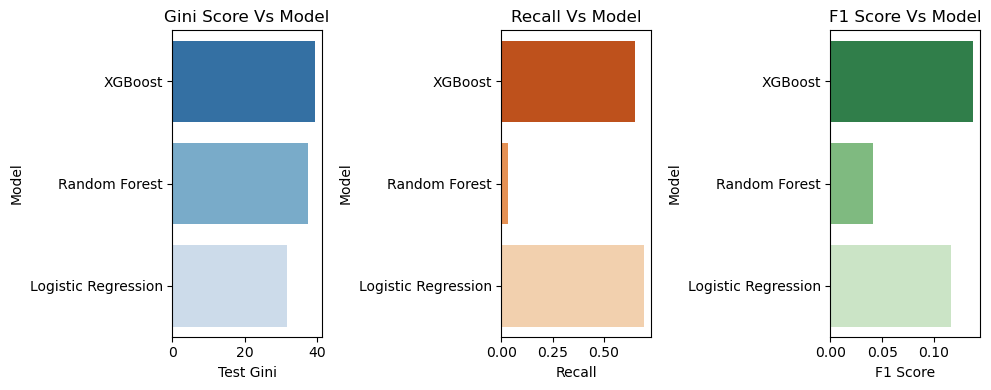

In [102]:
fig,ax=plt.subplots(1,3,figsize=(10,4))
sns.barplot(x="Test Gini",y="Model",data=final_model,palette="Blues_r",ax=ax[0])
ax[0].set_title("Gini Score Vs Model")
sns.barplot(x="Recall",y="Model",data=final_model,palette="Oranges_r",ax=ax[1])
ax[1].set_title("Recall Vs Model")
sns.barplot(x="F1 Score",y="Model",data=final_model,palette="Greens_r",ax=ax[2])
ax[2].set_title("F1 Score Vs Model")
plt.tight_layout()
plt.show()

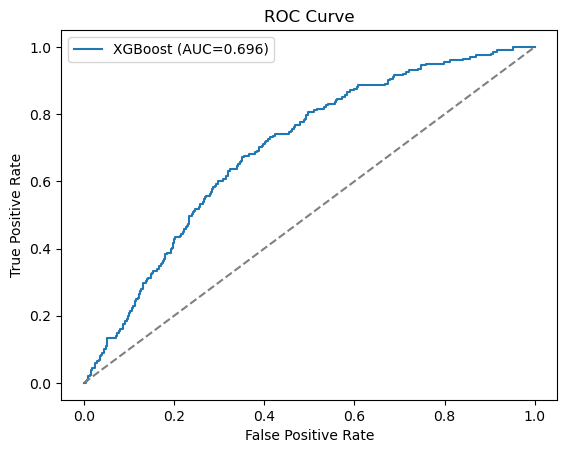

In [103]:
from sklearn.metrics import roc_curve, roc_auc_score
y_proba_xgb = best_estimators["XGBoost"].predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr, tpr, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.show()

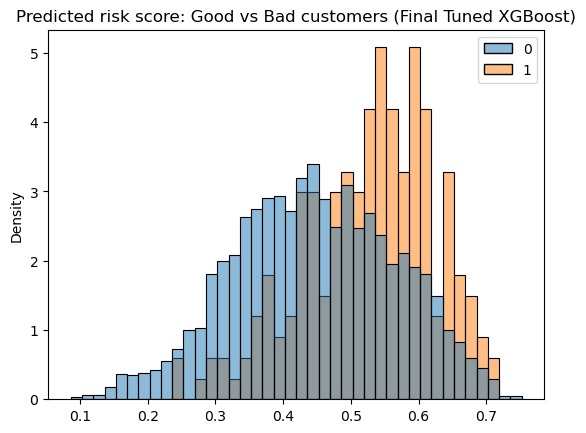

In [112]:
sns.histplot(x=y_proba_xgb, hue=y_test.values, bins=40, stat="density", common_norm=False, alpha=0.5)
plt.title("Predicted risk score: Good vs Bad customers (Final Tuned XGBoost)"); plt.show()

#### Feature importance

In [105]:
best_xg=best_estimators["XGBoost"]
importance_df=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":best_xg.feature_importances_
}).sort_values("Importance",ascending=False).reset_index(drop=True)
importance_df["Importance"]=importance_df["Importance"]/importance_df["Importance"].sum()
importance_df.head(20)

,Feature,Importance
0,feature_7,0.056371
1,feature_12_PM1,0.037632
2,feature_52,0.032267
3,feature_32_Paren,0.029562
4,feature_1_Titanium Deligh,0.027010
5,feature_36_Private Ltd. Co.,0.026196
6,feature_3,0.024997
7,feature_60_N,0.023669
8,avg_dpd_0_29,0.023275
9,avg_months_reported,0.023223


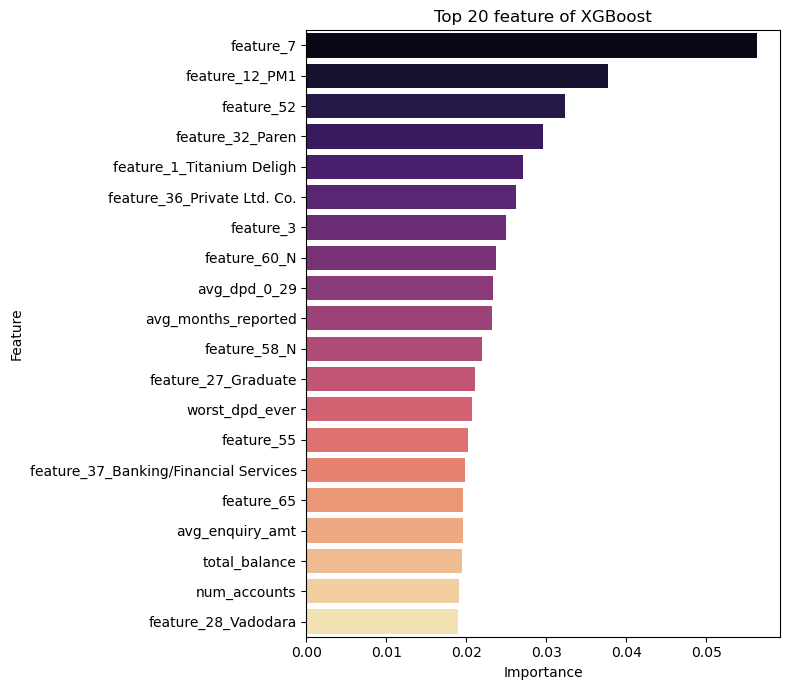

In [106]:
top20=importance_df.head(20).sort_values("Importance",ascending=False)
plt.figure(figsize=(8,7))
sns.barplot(y=top20["Feature"],x=top20["Importance"],palette='magma', hue=top20["Feature"])
plt.title("Top 20 feature of XGBoost")
plt.tight_layout()
plt.show()

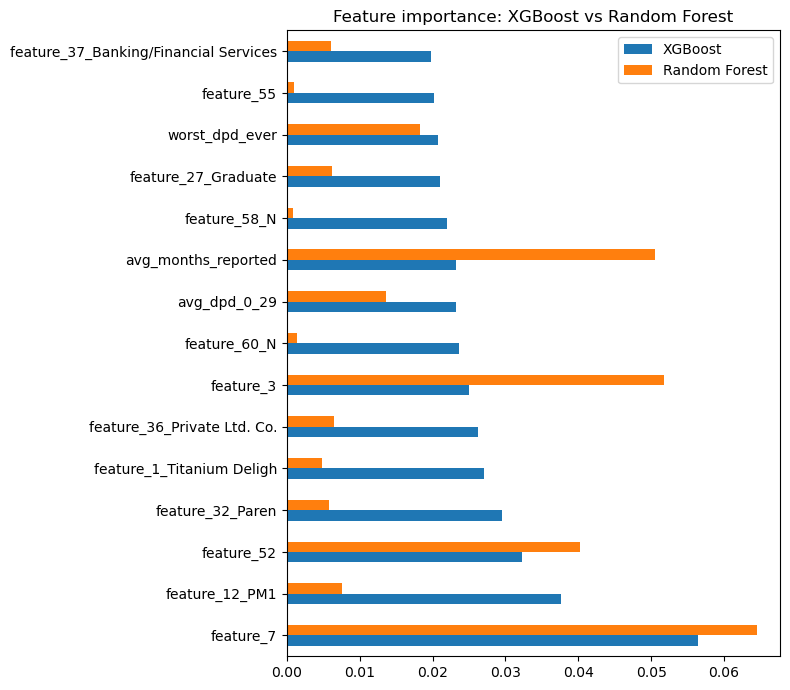

In [107]:
rf_imp = pd.Series(best_estimators["Random Forest"].feature_importances_, index=X_train.columns)
xgb_imp = pd.Series(best_estimators["XGBoost"].feature_importances_, index=X_train.columns)
top_features = importance_df["Feature"].head(15)
compare_df = pd.DataFrame({"XGBoost": xgb_imp[top_features], "Random Forest": rf_imp[top_features]})
compare_df.plot(kind="barh", figsize=(8,7)); plt.title("Feature importance: XGBoost vs Random Forest"); plt.tight_layout(); plt.show()

#### Decile Rank Ordering

In [108]:
xgb_final=best_estimators["XGBoost"]
y_prob_final=xgb_final.predict_proba(X_test)[:,1]
def decile_rank_ordering(y_true,y_score):
    df=pd.DataFrame({"y":np.array(y_true),"score":y_score})
    df["decile"]=pd.qcut(df["score"],10,labels=False,duplicates="drop")+1
    ro=df.groupby("decile")["y"].agg(["count","sum","mean"]).rename(columns={"count":"total_customer","sum":"bad_customer","mean":"bad_rate"})
    ro["bad_rate_pct"]=ro["bad_rate"]*100
    return ro.sort_index(ascending=False)
rank_order=decile_rank_ordering(y_test,y_prob_final)
print(rank_order)

        total_customer  bad_customer  bad_rate  bad_rate_pct
decile                                                      
10                 478            38  0.079498      7.949791
9                  478            40  0.083682      8.368201
8                  478            39  0.081590      8.158996
7                  478            22  0.046025      4.602510
6                  478            17  0.035565      3.556485
5                  478            18  0.037657      3.765690
4                  478            10  0.020921      2.092050
3                  478             7  0.014644      1.464435
2                  478             5  0.010460      1.046025
1                  478             5  0.010460      1.046025


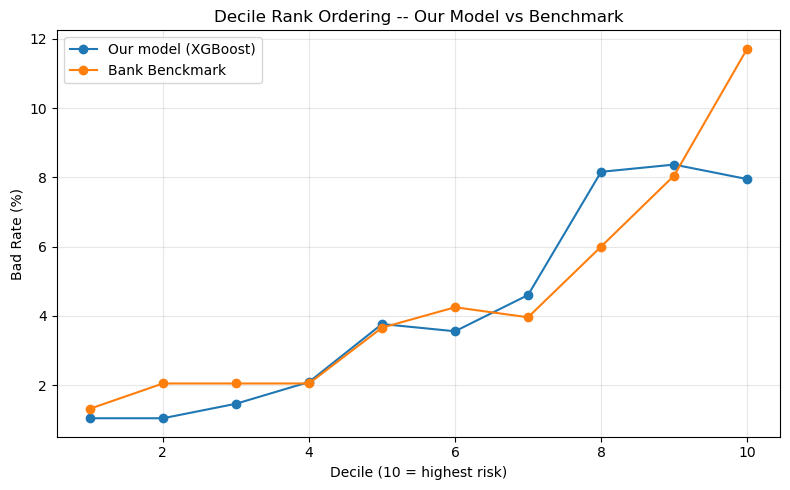

In [109]:
benchmark = pd.Series({
    10: 11.71, 9: 8.05, 8: 6.00, 7: 3.96, 6: 4.25,
    5: 3.66, 4: 2.05, 3: 2.05, 2: 2.05, 1: 1.32,
}, name="benchmark_bad_rate").sort_index(ascending=False)
fig,ax=plt.subplots(figsize=(8,5))
rank_order["bad_rate_pct"].plot(marker='o',label="Our model (XGBoost)",ax=ax)
benchmark.plot(marker='o',label="Bank Benckmark",ax=ax)
ax.set_xlabel("Decile (10 = highest risk)")
ax.set_ylabel("Bad Rate (%)")
ax.set_title("Decile Rank Ordering -- Our Model vs Benchmark")
ax.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

#### Report on Challenges faced

#### 1. Duplicate Records Across Source Tables
##### Challenge: The Cust_Account table contained 2,401 duplicate rows, and the Cust_Enquiry table also contained duplicates, both of which would double-count history for the affected customers when aggregated.
##### Technique Used: Identified duplicates using .duplicated().sum() and removed them with .drop_duplicates() before any aggregation.
##### Reason: Duplicate rows silently inflate count-based aggregates (e.g. number of accounts, number of enquiries), biasing the model toward the affected customers.
#### 2.Multiple Tables at Different Granularities
##### Challenge: The demographics table had one row per customer, while account and enquiry data had multiple rows per customer, so the data could not be merged directly for modeling.
##### Technique Used: Used groupby('customer_no').agg() to roll up account and enquiry records into per-customer summaries (num_accounts, avg_credit_limit, total_balance, num_enquiry, avg_enquiry_amt), then merged them onto the demographics table.
##### Reason: A supervised model requires exactly one feature row per labeled customer; aggregation condenses variable-length history into a fixed, comparable feature set.
#### 3. Decoding Raw Payment History Strings
##### Challenge: The payment history column stored a single concatenated string of 3-character monthly status codes (e.g. "STD", "XXX", or numeric days-past-due), with no direct numeric meaning.
##### Technique Used: Built a custom parser that split the string into monthly codes, mapped STD to 0 and XXX to an excluded sentinel value, kept numeric codes as integer DPD, then aggregated into avg_dpd_0_29, worst_dpd_ever, and avg_months_reported.
##### Reason: This converted an opaque bureau-format string into interpretable numeric risk indicators summarizing recent repayment behavior and worst historical delinquency.
#### 4. Two-Digit Year Parsing Bug in Date of Birth
##### Challenge: Dates of birth with two-digit years were parsed ambiguously (e.g. "03-Sep-65" read as 2065 instead of 1965), which would have produced negative or impossible ages.
##### Technique Used: Detected parsed years beyond a plausible range and subtracted 100 years to correct the century; computed age using a reference date derived from the dataset's own latest application date rather than today's date.
##### Reason: Anchoring to the dataset's own date range kept ages internally consistent, whereas using today's date would have inflated every age by the years since data collection.
#### 5. High-Cardinality Columns Disguised as Categorical
##### Challenge: Several anonymized feature columns were actually identifier-like fields (masked PAN numbers, phone numbers, branch/product codes) with thousands of unique values rather than true categories.
##### Technique Used: Inspected unique-value counts for every categorical column, separated true low/medium-cardinality categories from ID-like high-cardinality ones, and dropped the identifier columns.
##### Reason: One-hot encoding a column with thousands of unique values would create thousands of near-empty dummy columns, causing severe overfitting for no real predictive value.
#### 6. Extreme Outliers and Infinities in Continuous Features
##### Challenge: Several engineered columns (e.g. avg_enquiry_amt, total_balance) had extreme values up to ~800x their 75th percentile, and some divide-by-zero cases produced infinities.
##### Technique Used: Replaced infinities with NaN, then clipped each continuous column to its 1st–99th percentile range, with bounds computed from the training set only and applied to both train and test.
##### Reason: Unclipped extreme values risked numeric overflow during SMOTE and destabilized coefficient estimation in logistic regression; train-only bounds avoided leaking test-set information.
#### 7. clipping binary dummy columns would zero out every occurrence
##### Challenge: An early version of the clipping step selected every numeric-dtype column, which after one-hot encoding also swept in binary 0/1 dummy columns.
##### Technique Used: Rebuilt the column list to separate true continuous features from binary dummy columns, and restricted percentile clipping to the continuous columns only.
##### Reason: For a rare dummy flag, the 1st and 99th percentile are both 0, so blanket clipping would have zeroed out every occurrence of that flag, destroying signal from rare but important categories like fraud-check failures.

#### 8. Duplicate and Redundant Engineered Columns
##### Challenge: Two continuous columns were found to be exact duplicates, and a systematic check subsequently uncovered 33 further duplicate or redundant columns, including a 13-column cluster that were all identical.
##### Technique Used: Ran a pairwise equality scan across all numeric columns, grouped duplicate pairs into connected components to catch indirect duplicate chains, and kept one representative column per group.
##### Reason: Redundant, perfectly correlated columns add no new information and can destabilize coefficient estimates in linear models; a graph-based check catches chained duplicates a manual scan would miss.
#### 9. Severe Class Imbalance in the Target
##### Challenge: The target variable was heavily imbalanced (95.8% good customers vs. 4.2% bad customers), causing most classifiers to default toward predicting the majority class.
##### Technique Used: Compared two mitigation strategies across seven model families: SMOTE oversampling (applied only inside the training pipeline) and class_weight='balanced'.
##### Reason: Neither technique is universally superior, so testing both against the same models and metrics allowed an evidence-based choice.
#### 9.Accuracy Was a Misleading Evaluation Metric
##### Challenge: Several models scored over 95% accuracy while predicting zero bad customers at the default threshold, making a non-functional model look successful.
##### Technique Used: Switched the primary evaluation metric to ROC-AUC and Gini (2×AUC−1), which are threshold-independent, while still reporting precision, recall, and F1.
##### Reason: AUC/Gini measures how well the model ranks customers by risk regardless of threshold, which is what actually matters for a credit-scoring use case.
#### 10. Tuned Logistic Regression, Random Forest, and XGBoost
##### Challenge: Choosing a final model required more than comparing a single metric — it needed to be defensible in business terms.
##### Technique Used: Tuned Logistic Regression, Random Forest, and XGBoost using GridSearchCV (3-fold, scoring=roc_auc), then built a decile rank-ordering table and compared it against the bank's own historical benchmark bad rates.
##### Reason: Decile rank-ordering benchmarked against real bank performance is the standard way risk models are validated in practice, showing that bad customers concentrate in the highest-risk deciles.

### Conclusion

##### The majority of effort in this project went into reconciling data structure and quality issues — multi-table granularity, duplicate rows and duplicate columns, high-cardinality identifiers, and a genuine parsing bug in the date field — before any model was trained. Once the feature set was cleaned, deduplicated, and correctly scoped for clipping, the remaining challenge was the severe class imbalance in the target, which was addressed by comparing resampling and class-weighting strategies under a threshold-independent metric. The final tuned XGBoost model showed clear, monotonic separation between risk deciles when benchmarked against the bank's own historical bad rates, indicating the cleaning and feature-engineering effort translated into a model with genuine discriminative power rather than one that merely fit metric noise.

In [110]:
import joblib
joblib.dump(best_estimators["XGBoost"],"xgboost_credit_risk_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [111]:
loaded_model=joblib.load("xgboost_credit_risk_model.pkl")
y_pred = loaded_model.predict(X_test)